# Dictator Game

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from pydantic import BaseModel, Field
from typing import Literal


from src.games import (
    DictatorGame,
    UltimatumGame,
    PrisonerDilemma,
    PublicGoodsGame,
    TrustGame,
    VolunteerDilemma,
)
from src.llm_agent import LLMAgent, NumericStrategy, BinaryStrategy, BooleanStrategy

In [53]:
endowment = 100

In [54]:
USER_PROMPT_DICTATOR=f"""
You have ${endowment}. 
Decide how much to give to the other player.
"""
SYSTEM_PROMPT = open('./src/games/prompts/default_system_prompt.txt').read()

In [55]:
agent = LLMAgent(model="qwen2.5:14b-multi")

In [61]:
class NumericStrategy_Dictator(BaseModel):
    value: float = Field(description="How many $ to give to the other player.")
    #note: str = Field(description="A one sentence description explaining your choice.")

In [62]:
N = 385
choices = [agent.play(USER_PROMPT_DICTATOR, NumericStrategy_Dictator, system_prompt=SYSTEM_PROMPT) for _ in range(N)]

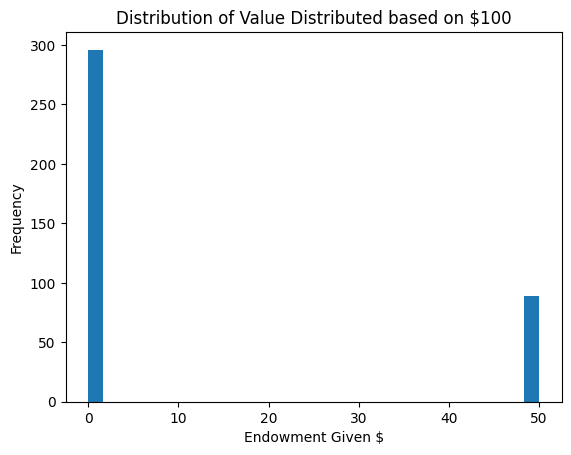

In [64]:
df = pd.DataFrame([c.model_dump() for c in choices])
df['value'].hist(bins=30)
plt.title(f"Distribution of Value Distributed based on ${endowment}")
plt.xlabel("Endowment Given $")
plt.ylabel("Frequency")
plt.grid()

In [60]:
df

,value,note
0,0.0,Since this scenario does not provide informati...
1,0.0,Since this interaction does not specify the co...
2,0.0,Since this interaction does not specify rules ...
3,50.0,Since this isn't framed as a game with specifi...
4,0.0,Since this scenario does not provide details a...
5,50.0,I'm choosing an amount that is significant but...
6,0.0,Since this interaction does not provide contex...
7,0.0,Since this interaction does not specify the co...
8,0.0,Since this interaction does not specify rules ...
9,0.0,Since this appears to be an instruction in a h...
